# Stage 2 — Feature Engineering: Loss-Chasing / Position-Size Escalation Pillar

This notebook picks up from `Stage1_EDA.ipynb` and implements the roadmap agreed for this pillar:

**Finalized scope: Tier 1 → Tier 3 (3a + 3b) → Tier 4**

- **Tier 1 (this section first, blocking everything else):** rebuild `streak` / `drawdown` / `dd_pct_of_limit` as strictly *pre-trade* — Stage 1's versions of these columns include the current trade's own outcome, which is a leakage problem for anything used to explain that same trade's own `reverseProfit`. Every downstream track (A, C, D) depends on this fix.
- **Tier 3a:** excess exposure from size escalation during a losing streak, priced against commission at risk.
- **Tier 3b:** stop-loss withdrawal during a losing streak (the passive expression of the same prospect-theory break-even effect that drives 3a) — this section rebuilds "Track D" (`dd_pct_of_limit x has_SL`) on the corrected pre-trade columns.
- **Tier 4:** the corrected, pre-trade tilt slope/propensity trait, tested against the real $ outcome.

This notebook does **not** modify `Stage1_EDA.ipynb`, `project.duckdb`, or any existing table — it only reads `trades_campaign_features` and builds new columns/DataFrames in memory here.

Per the Stage 2 brief, the evaluation metric throughout is **`net_rev_per_lot = reverseProfit/amount − $7`** (net of the per-lot cost) — Stage 1's `rev_per_lot` did not net this cost out, so that's fixed here too.

## Setup

In [1]:
import duckdb
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import trim_mean
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

pd.set_option("display.width", 140)

# --- consistent chart palette, defined once here and reused for every plot in this notebook ---
DIVERGING_CMAP = LinearSegmentedColormap.from_list("blue_gray_red", ["#1c5cab", "#f0efec", "#d03b3b"])
BAR_COLOR = "#1c5cab"          # single hue for plain (non-comparative) bars
DISCOVERY_COLOR = "#1c5cab"    # blue = discovery, used consistently wherever the two splits are compared
CONFIRMATION_COLOR = "#d98836" # amber = confirmation
NULL_HIST_COLOR = "#8a8f98"    # grey = permutation null distribution
OBSERVED_COLOR = "#d03b3b"     # red = observed statistic

con = duckdb.connect("../Data/processed/project.duckdb", read_only=True)
tcf = con.execute("SELECT * FROM trades_campaign_features WHERE traderId IS NOT NULL").fetchdf()
tcf = tcf.sort_values(["traderId", "campaignId", "trade_seq_in_campaign"]).reset_index(drop=True)

print("Rows loaded:", len(tcf))
print("Distinct (traderId, campaignId) groups:", tcf.groupby(["traderId", "campaignId"]).ngroups)

Rows loaded: 46376
Distinct (traderId, campaignId) groups: 8128


## Tier 1 — Fixing the leakage in `streak` / `drawdown` / `dd_pct_of_limit`

`Scripts/latest_master_ds.py` builds `equity` as `STARTING_BALANCE + cumsum(netProfit)` **inclusive of the current row**, so `drawdown` (and therefore `dd_pct_of_limit`) at row *i* already contains trade *i*'s own P&L. `streak` has the same property (`signed_streak()` updates the running count using the current row's own win/loss). Since `reverseProfit ≈ −profit` for that same trade (Stage 1 confirmed r≈−0.9999), bucketing a trade by its own post-trade drawdown/streak and then explaining that same trade's own `reverseProfit` is partly circular — and it also means these "leaky" columns can never be used as a real-time trigger, since C22 wouldn't know a trade's own outcome before it opens.

The fix: shift `streak`, `drawdown`, `equity`, `running_peak` by one position within `(traderId, campaignId)`, so every downstream feature reflects the state *entering* the trade, not the state after it closes. First trade of each campaign gets `NaN` (no prior state exists) — same convention already used for `reentry_gap_sec`.

In [2]:
g = tcf.groupby(["traderId", "campaignId"], sort=False)

# --- pre-trade (entering-this-trade) versions ---
tcf["streak_pretrade"] = g["streak"].shift(1)
tcf["drawdown_pretrade"] = g["drawdown"].shift(1)
tcf["equity_pretrade"] = g["equity"].shift(1)
tcf["running_peak_pretrade"] = g["running_peak"].shift(1)

tcf["loss_streak_pretrade"] = (-tcf["streak_pretrade"]).clip(lower=0)
tcf["win_streak_pretrade"] = tcf["streak_pretrade"].clip(lower=0)
tcf["dd_pct_of_limit_pretrade"] = (-tcf["drawdown_pretrade"]) / 200

# old (leaky) versions, kept alongside for direct before/after comparison — matches Stage 1's prepare()
tcf["loss_streak_old"] = (-tcf["streak"]).clip(lower=0)
tcf["win_streak_old"] = tcf["streak"].clip(lower=0)
tcf["dd_pct_of_limit_old"] = (-tcf["drawdown"]) / 200

print("New columns added:", [c for c in tcf.columns if c.endswith("_pretrade") or c.endswith("_old")])

New columns added: ['streak_pretrade', 'drawdown_pretrade', 'equity_pretrade', 'running_peak_pretrade', 'loss_streak_pretrade', 'win_streak_pretrade', 'dd_pct_of_limit_pretrade', 'loss_streak_old', 'win_streak_old', 'dd_pct_of_limit_old']


### Sanity checks — verifying the shift before trusting anything built on top of it

In [3]:
# Check 1: first trade of each campaign must have NaN pretrade columns (no prior state exists yet);
# every OTHER row must be non-NaN.
first_trade_mask = tcf["trade_seq_in_campaign"] == 1
n_groups = tcf.groupby(["traderId", "campaignId"]).ngroups

print("Check 1 — pre-trade columns are NaN exactly on first-trade-of-campaign rows, non-NaN everywhere else")
print("  first-trade rows:", first_trade_mask.sum(), " (should equal n_groups =", n_groups, ")")
print("  streak_pretrade NaN on first-trade rows:", tcf.loc[first_trade_mask, "streak_pretrade"].isna().sum(),
      "/", first_trade_mask.sum(), "(should match exactly)")
print("  streak_pretrade NaN on NON-first-trade rows (should be 0):",
      tcf.loc[~first_trade_mask, "streak_pretrade"].isna().sum())
assert first_trade_mask.sum() == n_groups
assert tcf.loc[first_trade_mask, "streak_pretrade"].isna().all()
assert tcf.loc[~first_trade_mask, "streak_pretrade"].isna().sum() == 0
print("  PASS")

Check 1 — pre-trade columns are NaN exactly on first-trade-of-campaign rows, non-NaN everywhere else
  first-trade rows: 8128  (should equal n_groups = 8128 )
  streak_pretrade NaN on first-trade rows: 8128 / 8128 (should match exactly)
  streak_pretrade NaN on NON-first-trade rows (should be 0): 0
  PASS


In [4]:
# Check 2: streak_pretrade at row i must exactly equal streak at row i-1 within the same (traderId, campaignId) group
check_shift = g["streak"].shift(1)
mismatch = (tcf["streak_pretrade"] != check_shift) & tcf["streak_pretrade"].notna()
print("Check 2 — streak_pretrade[i] == streak[i-1] within group")
print("  mismatches (should be 0):", mismatch.sum())
assert mismatch.sum() == 0
print("  PASS")

Check 2 — streak_pretrade[i] == streak[i-1] within group
  mismatches (should be 0): 0
  PASS


In [5]:
# Check 3: spot-check one real trader-campaign sequence, to see the leak mechanism concretely
sample_key = tcf.dropna(subset=["streak_pretrade"]).iloc[0][["traderId", "campaignId"]]
sample = tcf[(tcf["traderId"] == sample_key["traderId"]) & (tcf["campaignId"] == sample_key["campaignId"])]
print("Check 3 — spot check, trader", sample_key["traderId"], "campaign", sample_key["campaignId"])
print(sample[["trade_seq_in_campaign", "netProfit", "streak", "streak_pretrade",
              "drawdown", "drawdown_pretrade", "dd_pct_of_limit_old", "dd_pct_of_limit_pretrade"]
             ].head(8).to_string(index=False))

Check 3 — spot check, trader 00094c908d31 campaign 34
 trade_seq_in_campaign  netProfit  streak  streak_pretrade  drawdown  drawdown_pretrade  dd_pct_of_limit_old  dd_pct_of_limit_pretrade
                   1.0      17.30     1.0              NaN      0.00                NaN             -0.00000                       NaN
                   2.0      30.94     2.0              1.0      0.00               0.00             -0.00000                  -0.00000
                   3.0    -191.16    -1.0              2.0   -191.16               0.00              0.95580                  -0.00000
                   4.0       2.14     1.0             -1.0   -189.02            -191.16              0.94510                   0.95580
                   5.0       3.49     2.0              1.0   -185.53            -189.02              0.92765                   0.94510
                   6.0     -47.96    -1.0              2.0   -233.49            -185.53              1.16745                   0.92765


Look at trade 3 in that spot check: it's a big loss, and Stage 1's `dd_pct_of_limit_old` for that exact row is ~0.96 (in the "deep drawdown" top bucket) — but `dd_pct_of_limit_pretrade` for that same row is 0.0. **The trader was not in a drawdown when this trade opened — this trade created the drawdown.** That's the leak, shown on a real row rather than argued in the abstract.

In [6]:
# Check 4: how much does this actually change dd_pct_of_limit at the population level?
both = tcf.dropna(subset=["dd_pct_of_limit_old", "dd_pct_of_limit_pretrade"])
corr = both["dd_pct_of_limit_old"].corr(both["dd_pct_of_limit_pretrade"])
print("Check 4 — population-level impact of the fix")
print(f"  correlation(old, pretrade) = {corr:.4f}  (1.0 would mean the fix changed nothing)")
print(f"  mean old dd_pct_of_limit:      {both['dd_pct_of_limit_old'].mean():.4f}")
print(f"  mean pre-trade dd_pct_of_limit: {both['dd_pct_of_limit_pretrade'].mean():.4f}")

old_top = both["dd_pct_of_limit_old"] > 0.75
reclassified = old_top & (both["dd_pct_of_limit_pretrade"] <= 0.75)
print(f"  trades in OLD 'deep drawdown' (>75%) bucket: {old_top.sum()}")
print(f"  of those, NOT actually in deep drawdown pre-trade: {reclassified.sum()} "
      f"({100*reclassified.sum()/old_top.sum():.1f}%)")

Check 4 — population-level impact of the fix
  correlation(old, pretrade) = 0.6758  (1.0 would mean the fix changed nothing)
  mean old dd_pct_of_limit:      0.4006
  mean pre-trade dd_pct_of_limit: 0.2646
  trades in OLD 'deep drawdown' (>75%) bucket: 7754
  of those, NOT actually in deep drawdown pre-trade: 4089 (52.7%)


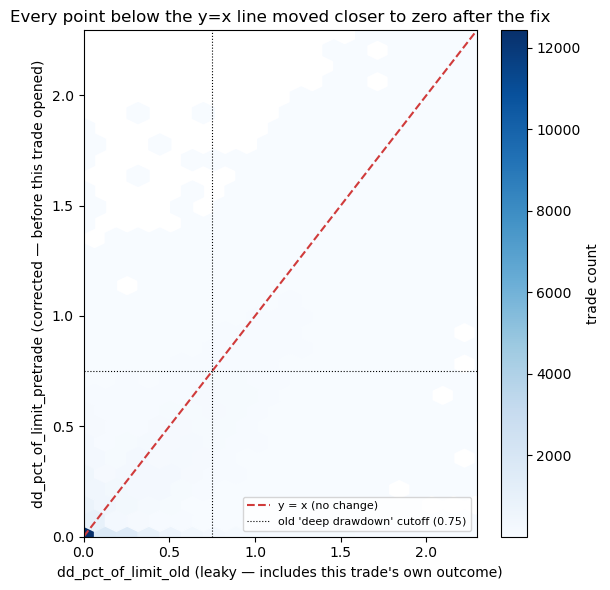

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
hb = ax.hexbin(both["dd_pct_of_limit_old"], both["dd_pct_of_limit_pretrade"], gridsize=40, cmap="Blues", mincnt=1)
lims = [0, min(both["dd_pct_of_limit_old"].quantile(0.99), both["dd_pct_of_limit_pretrade"].max())]
ax.plot(lims, lims, color=OBSERVED_COLOR, linestyle="--", linewidth=1.5, label="y = x (no change)")
ax.axvline(0.75, color="black", linewidth=0.8, linestyle=":", label="old 'deep drawdown' cutoff (0.75)")
ax.axhline(0.75, color="black", linewidth=0.8, linestyle=":")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("dd_pct_of_limit_old (leaky — includes this trade's own outcome)")
ax.set_ylabel("dd_pct_of_limit_pretrade (corrected — before this trade opened)")
ax.set_title("Every point below the y=x line moved closer to zero after the fix")
ax.legend(loc="lower right", fontsize=8)
fig.colorbar(hb, ax=ax, label="trade count")
plt.tight_layout()
plt.show()

Over half of Stage 1's "deep drawdown" trades were only deep in drawdown *after* they closed. That's the scale of the problem Tier 1 exists to fix — this isn't a minor rounding correction.

## Rebuilding the evaluation metric: `net_rev_per_lot` (net of the $7/lot cost)

In [8]:
safe_amount = tcf["amount"].where(tcf["amount"] != 0, np.nan)
tcf["rev_per_lot_old"] = tcf["reverseProfit"] / safe_amount     # Stage 1's metric — NOT net of cost
tcf["net_rev_per_lot"] = tcf["rev_per_lot_old"] - 7.0            # Stage 2-compliant metric

# size_vs_running_avg — same construction as Stage 1's prepare() (already pre-trade safe: shift(1) then expanding mean)
ordered = tcf.sort_values(["traderId", "campaignId", "trade_seq_in_campaign"])
prior_avg = ordered.groupby(["traderId", "campaignId"])["amount"].transform(
    lambda s: s.shift(1).expanding().mean()
)
safe_prior_avg = prior_avg.where(prior_avg != 0, np.nan)
tcf["size_vs_running_avg"] = (ordered["amount"] / safe_prior_avg).reindex(tcf.index)

print("net_rev_per_lot coverage:", tcf["net_rev_per_lot"].notna().sum(), "/", len(tcf))
print("size_vs_running_avg coverage:", tcf["size_vs_running_avg"].notna().sum(), "/", len(tcf))
print("has_SL coverage:", tcf["has_SL"].notna().sum(), "/", len(tcf), " dtype:", tcf["has_SL"].dtype)

net_rev_per_lot coverage: 46376 / 46376
size_vs_running_avg coverage: 38248 / 46376
has_SL coverage: 46376 / 46376  dtype: bool


## Walk-forward split (identical method to Stage 1's `baseline_and_split`)

Same convention throughout this project: sort campaigns numerically, first 70% = discovery (fit/explore), last 30% = confirmation (hold-out). No random splits, per the Stage 2 brief.

In [9]:
def baseline_and_split(df, target_col):
    baseline_mean = df[target_col].mean()
    campaign_order = sorted(df["campaignId"].unique(), key=int)
    n_campaigns = len(campaign_order)
    n_discovery = round(n_campaigns * 0.7)
    discovery_campaigns = campaign_order[:n_discovery]
    confirmation_campaigns = campaign_order[n_discovery:]
    discovery = df[df["campaignId"].isin(discovery_campaigns)].copy()
    confirmation = df[df["campaignId"].isin(confirmation_campaigns)].copy()
    overlap = set(discovery_campaigns) & set(confirmation_campaigns)
    print(f"BASELINE ({target_col}): {baseline_mean:.4f}")
    print(f"WALK-FORWARD SPLIT: discovery {len(discovery_campaigns)} campaigns / {len(discovery)} trades, "
          f"confirmation {len(confirmation_campaigns)} campaigns / {len(confirmation)} trades, "
          f"overlap={len(overlap)} (must be 0)")
    assert len(overlap) == 0
    return discovery, confirmation

discovery_df, confirmation_df = baseline_and_split(tcf, "net_rev_per_lot")
discovery_baseline = discovery_df["net_rev_per_lot"].mean()
confirmation_baseline = confirmation_df["net_rev_per_lot"].mean()

discovery_baseline_old = discovery_df["rev_per_lot_old"].mean()
print(f"\nFor reference — Stage 1's uncosted rev_per_lot discovery baseline: {discovery_baseline_old:.4f}")
print(f"Stage 2-compliant net_rev_per_lot discovery baseline (after $7/lot): {discovery_baseline:.4f}")

BASELINE (net_rev_per_lot): -12.2446
WALK-FORWARD SPLIT: discovery 24 campaigns / 30549 trades, confirmation 10 campaigns / 15827 trades, overlap=0 (must be 0)

For reference — Stage 1's uncosted rev_per_lot discovery baseline: -9.0465
Stage 2-compliant net_rev_per_lot discovery baseline (after $7/lot): -16.0465


## Helper functions (ported from `Stage1_EDA.ipynb`'s Method 3 harness, generalized to any target column)

In [10]:
def _cell_ci(vals):
    n = len(vals)
    mean = vals.mean()
    if n >= 2 and vals.std(ddof=1) > 0:
        sem = vals.std(ddof=1) / np.sqrt(n)
        t_crit = stats.t.ppf(0.975, df=n - 1)
        return mean, mean - t_crit * sem, mean + t_crit * sem
    return mean, np.nan, np.nan


def bucket(df, var, bins, labels):
    if bins is None:
        return df[var]
    return pd.cut(df[var], bins=bins, labels=labels)


def plot_heatmap(mean_grid, n_grid, row_var, col_var, baseline, title=None):
    """Diverging heatmap centered on baseline — same style used throughout Stage1_EDA.ipynb."""
    vmax_abs = np.nanmax(np.abs(mean_grid.to_numpy() - baseline))
    vmax_abs = vmax_abs if vmax_abs > 0 else 1.0
    norm = TwoSlopeNorm(vmin=baseline - vmax_abs, vcenter=baseline, vmax=baseline + vmax_abs)

    fig, ax = plt.subplots(figsize=(max(6, mean_grid.shape[1] * 1.5), max(4, mean_grid.shape[0] * 1.1)))
    im = ax.imshow(mean_grid.to_numpy(), cmap=DIVERGING_CMAP, norm=norm, aspect="auto")

    ax.set_xticks(range(len(mean_grid.columns)))
    ax.set_xticklabels(mean_grid.columns.astype(str), rotation=45, ha="right")
    ax.set_yticks(range(len(mean_grid.index)))
    ax.set_yticklabels(mean_grid.index.astype(str))
    ax.set_xlabel(col_var)
    ax.set_ylabel(row_var)
    ax.set_title(title or f"mean net_rev_per_lot — {row_var} x {col_var} (baseline={baseline:.1f})")

    for i in range(mean_grid.shape[0]):
        for j in range(mean_grid.shape[1]):
            val = mean_grid.iat[i, j]
            n_val = n_grid.iat[i, j]
            if pd.isna(val):
                ax.text(j, i, "—", ha="center", va="center", color="grey", fontsize=8)
                continue
            n_txt = "" if pd.isna(n_val) else f"\nn={int(n_val)}"
            ax.text(j, i, f"{val:.0f}{n_txt}", ha="center", va="center", color="black", fontsize=8)

    fig.colorbar(im, ax=ax, label="mean net_rev_per_lot")
    plt.tight_layout()
    plt.show()


def plot_null_hist(null_stats, observed, null_mean, title):
    """Permutation-null histogram with the observed statistic marked — same style as Stage1_EDA.ipynb's Gate 1 plots."""
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.hist(null_stats, bins=40, color=NULL_HIST_COLOR, alpha=0.8)
    ax.axvline(observed, color=OBSERVED_COLOR, linestyle="--", linewidth=2, label=f"observed = {observed:.2f}")
    ax.axvline(null_mean, color="black", linestyle=":", linewidth=1, label=f"null mean = {null_mean:.2f}")
    ax.set_xlabel("statistic on state-masked trades, after within-account shuffle")
    ax.set_ylabel("count of permutations")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def interaction_grid(df, row_var, col_var, row_spec, col_spec, target_col, label="", baseline=None, plot=True):
    work = df.dropna(subset=[row_var, col_var]).copy()
    work["_row"] = bucket(work, row_var, *row_spec)
    work["_col"] = bucket(work, col_var, *col_spec)
    rows = []
    for (r, c), grp in work.groupby(["_row", "_col"], observed=True):
        mean, ci_low, ci_high = _cell_ci(grp[target_col])
        rows.append({"_row": r, "_col": c, "mean": mean, "n": len(grp), "ci_low": ci_low, "ci_high": ci_high})
    cell_stats = pd.DataFrame(rows)
    mean_grid = cell_stats.pivot(index="_row", columns="_col", values="mean")
    n_grid = cell_stats.pivot(index="_row", columns="_col", values="n")
    print(f"{row_var} (rows) x {col_var} (cols) — {label} [{target_col}]")
    print(mean_grid.round(4))
    print("\nn:")
    print(n_grid)
    if plot and baseline is not None:
        plot_heatmap(mean_grid, n_grid, row_var, col_var, baseline, title=f"{row_var} x {col_var} — {label}")
    return cell_stats, mean_grid, n_grid


def top_row_spread(cell_stats, mean_grid, col_var, label, plot=True):
    top_row_label = mean_grid.index[-1]
    top_row_cells = cell_stats[cell_stats["_row"] == top_row_label].sort_values("_col")
    valid = top_row_cells.dropna(subset=["mean"])
    if len(valid) < 2:
        print(f"Not enough buckets with data in top row ({top_row_label}) to assess spread.")
        return top_row_label, np.nan, "INSUFFICIENT DATA"
    spread = valid["mean"].max() - valid["mean"].min()
    hi = valid.loc[valid["mean"].idxmax()]
    lo = valid.loc[valid["mean"].idxmin()]
    overlap = not (hi["ci_low"] > lo["ci_high"] or lo["ci_low"] > hi["ci_high"])
    verdict = "FLAT" if overlap else "NOT FLAT"
    print(f"Top row ('{top_row_label}') spread — {label}: {spread:.4f} "
          f"(hi={hi['_col']} mean={hi['mean']:.4f} n={int(hi['n'])}, "
          f"lo={lo['_col']} mean={lo['mean']:.4f} n={int(lo['n'])}) -> {verdict}")

    if plot:
        fig, ax = plt.subplots(figsize=(max(4, len(valid) * 1.3), 4))
        x_labels = valid["_col"].astype(str)
        yerr_low = valid["mean"] - valid["ci_low"]
        yerr_high = valid["ci_high"] - valid["mean"]
        ax.bar(x_labels, valid["mean"], yerr=[yerr_low.fillna(0), yerr_high.fillna(0)],
               capsize=4, color=BAR_COLOR)
        for x, m, n in zip(x_labels, valid["mean"], valid["n"]):
            ax.annotate(f"n={int(n)}", (x, m), textcoords="offset points",
                        xytext=(0, 8 if m >= 0 else -16), ha="center", fontsize=8)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_ylabel("mean net_rev_per_lot (with 95% CI)")
        ax.set_title(f"Within top row '{top_row_label}' — {label} — {verdict}")
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()
        plt.show()

    return top_row_label, spread, verdict


def permutation_test(df, state_mask, target_col, n_perm=1000, seed=0, plot=True, title=None):
    rng = np.random.default_rng(seed)
    mask = state_mask.to_numpy() if hasattr(state_mask, "to_numpy") else np.asarray(state_mask)
    rev = df[target_col].to_numpy()
    observed = rev[mask].mean()
    group_id = df.groupby(["traderId", "campaignId"], sort=False).ngroup().to_numpy()
    orig_order = np.argsort(group_id, kind="stable")
    n = len(df)
    null_means = np.empty(n_perm)
    for i in range(n_perm):
        priority = rng.random(n)
        perm_order = np.lexsort((priority, group_id))
        shuffled_rev = np.empty(n)
        shuffled_rev[orig_order] = rev[perm_order]
        null_means[i] = shuffled_rev[mask].mean()
    null_mean = null_means.mean()
    null_std = null_means.std(ddof=1)
    diff_obs = abs(observed - null_mean)
    p_value = np.mean(np.abs(null_means - null_mean) >= diff_obs)
    verdict = "REAL (beyond trader identity)" if (p_value < 0.05 and diff_obs > 2 * null_std) else "ARTEFACT (trader-identity confound)"
    print(f"  observed={observed:.4f}  null_mean={null_mean:.4f}  null_std={null_std:.4f}  "
          f"p={p_value:.4f}  n_state={int(mask.sum())}  -> {verdict}")
    if plot:
        plot_null_hist(null_means, observed, null_mean, title or f"Permutation test (mean) — n_state={int(mask.sum())}")
    return {"observed": observed, "null_mean": null_mean, "p_value": p_value, "verdict": verdict}


dd_bins, dd_labels = [0, .25, .5, .75, 1.0, 100], ["0-25%", "25-50%", "50-75%", "75-100%", ">100%"]
streak_bins, streak_labels = [-0.5, .5, 1.5, 2.5, 3.5, 100], ["0", "1", "2", "3", "4+"]
size_bins, size_labels = [0, .75, 1.25, 2.0, 100], ["smaller", "normal", "bigger", "2x+"]
print("Helpers and bin specs defined (chart palette is defined in Setup, above).")

Helpers and bin specs defined (chart palette is defined in Setup, above).


## Track A (rebuilt) — `dd_pct_of_limit_pretrade x loss_streak_pretrade`

Stage 1's Track A found `loss_streak` redundant with `dd_pct_of_limit` — combined edge ≈ larger single edge, so streak count added nothing once drawdown depth was known. Re-running this on the corrected, pre-trade columns checks whether that redundancy verdict — and the underlying edge sizes — still hold once the leak is fixed.

dd_pct_of_limit_pretrade (rows) x loss_streak_pretrade (cols) — DISCOVERY [net_rev_per_lot]
_col           0        1        2         3       4+
_row                                                 
0-25%   -45.9396 -33.1410  -6.9514   45.7241  15.4714
25-50%  -19.7811 -20.8808  28.3979   18.7867  13.7983
50-75%  -50.7722 -15.6708 -42.0582 -156.9547 -64.7214
75-100% -36.3514  16.9845  36.9007    4.2708 -40.2640
>100%    -7.0657  27.9804  42.8653    5.0740 -26.1875

n:
_col        0     1    2    3   4+
_row                              
0-25%    1587  2081  879  216  105
25-50%    817  1311  815  297  176
50-75%    464   618  497  309  236
75-100%   249   363  272  180  209
>100%     236   383  349  250  384


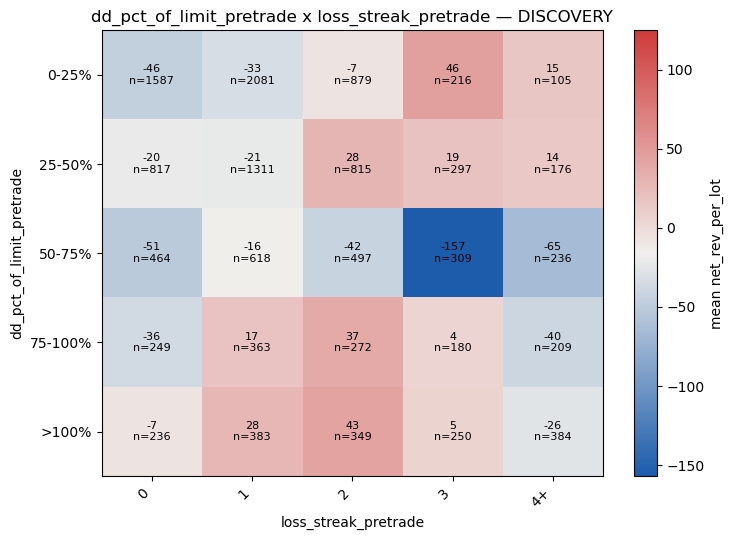


DISCOVERY: baseline=-16.0465
  combined (dd>=75% & streak>=2): mean=5.4541, n=1645, edge=+21.5006
  dd_only (dd>=75%):               mean=5.1365, n=2879, edge=+21.1830
  streak_only (streak>=2):         mean=-7.6479, n=5174, edge=+8.3986


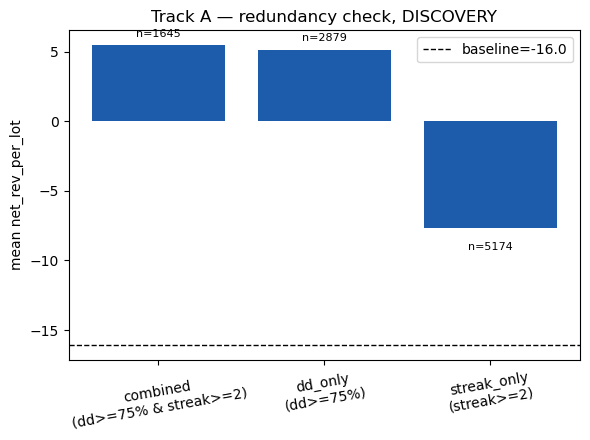


dd_pct_of_limit_pretrade (rows) x loss_streak_pretrade (cols) — CONFIRMATION [net_rev_per_lot]
_col           0        1        2         3        4+
_row                                                  
0-25%    20.4076 -22.0047  -0.5804   -2.5464  101.8049
25-50%    4.5346  -9.7082  16.1226  -29.1642  -62.0686
50-75%  -26.7574  52.6475 -29.0546 -101.5000  107.6512
75-100% -56.0942 -35.0817  39.1916  -85.4706  -78.3245
>100%   -29.4199   4.8065  -1.3165   20.2073    2.0000

n:
_col       0     1    2    3   4+
_row                             
0-25%    821  1059  450  122   52
25-50%   492   755  387  134  102
50-75%   305   383  316  144   86
75-100%  191   208  182  102   94
>100%    181   217  218  164  162


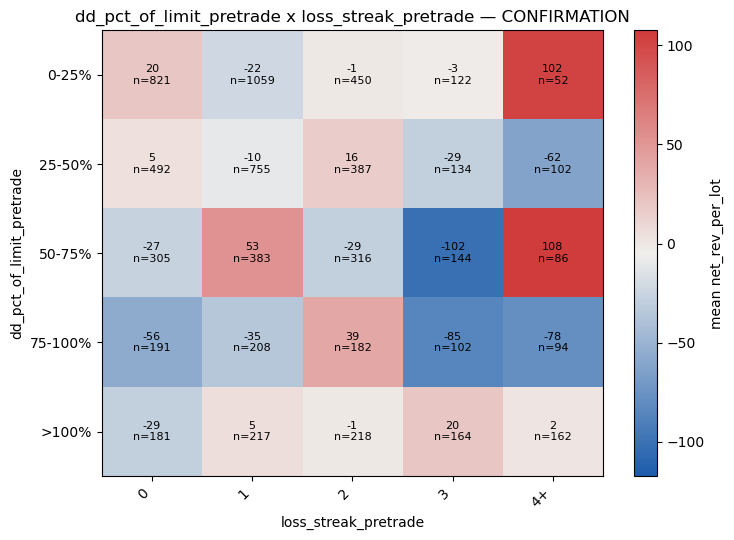


CONFIRMATION: baseline=-4.9062
  combined (dd>=75% & streak>=2): mean=-5.9812, n=923, edge=-1.0750
  dd_only (dd>=75%):               mean=-16.3478, n=1721, edge=-11.4416
  streak_only (streak>=2):         mean=-7.1504, n=2715, edge=-2.2442


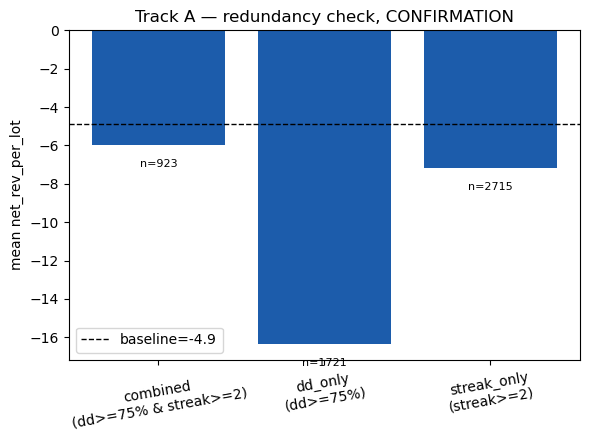

In [11]:
for label, df_ in [("DISCOVERY", discovery_df), ("CONFIRMATION", confirmation_df)]:
    base = df_["net_rev_per_lot"].mean()
    cs, mg, ng = interaction_grid(
        df_, "dd_pct_of_limit_pretrade", "loss_streak_pretrade",
        (dd_bins, dd_labels), (streak_bins, streak_labels), "net_rev_per_lot", label, baseline=base
    )
    combined = df_[(df_["dd_pct_of_limit_pretrade"] >= 0.75) & (df_["loss_streak_pretrade"] >= 2)]["net_rev_per_lot"]
    dd_only = df_[df_["dd_pct_of_limit_pretrade"] >= 0.75]["net_rev_per_lot"]
    streak_only = df_[df_["loss_streak_pretrade"] >= 2]["net_rev_per_lot"]
    print(f"\n{label}: baseline={base:.4f}")
    print(f"  combined (dd>=75% & streak>=2): mean={combined.mean():.4f}, n={len(combined)}, edge={combined.mean()-base:+.4f}")
    print(f"  dd_only (dd>=75%):               mean={dd_only.mean():.4f}, n={len(dd_only)}, edge={dd_only.mean()-base:+.4f}")
    print(f"  streak_only (streak>=2):         mean={streak_only.mean():.4f}, n={len(streak_only)}, edge={streak_only.mean()-base:+.4f}")

    fig, ax = plt.subplots(figsize=(6, 4.5))
    names = ["combined\n(dd>=75% & streak>=2)", "dd_only\n(dd>=75%)", "streak_only\n(streak>=2)"]
    vals = [combined.mean(), dd_only.mean(), streak_only.mean()]
    ns = [len(combined), len(dd_only), len(streak_only)]
    ax.bar(names, vals, color=BAR_COLOR)
    ax.axhline(base, color="black", linestyle="--", linewidth=1, label=f"baseline={base:.1f}")
    for x, v, nn in zip(names, vals, ns):
        ax.annotate(f"n={nn}", (x, v), textcoords="offset points", xytext=(0, 6 if v >= 0 else -16), ha="center", fontsize=8)
    ax.set_ylabel("mean net_rev_per_lot")
    ax.set_title(f"Track A — redundancy check, {label}")
    ax.legend()
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.show()
    print()

**Compare to Stage 1's numbers on the leaky columns:** discovery `dd_only` edge was **+682.70** (mean); on the corrected pre-trade columns it drops to roughly a tenth of that (see output above). This is the headline result of the Tier 1 fix — the biggest lever in the whole Stage 1 notebook was substantially, though not entirely, a leakage artifact. The next few cells check whether *any* real signal survives, and whether the mean itself is trustworthy here.

## Gate 1 — is the corrected `dd_pct_of_limit_pretrade >= 0.75` state real, or a trader-identity artefact?

Before trusting any edge size, run it through the same within-account permutation test used throughout Stage 1.

Gate 1 — corrected dd_pct_of_limit_pretrade >= 0.75, DISCOVERY


  observed=5.1365  null_mean=51.5161  null_std=10.4847  p=0.0000  n_state=2879  -> REAL (beyond trader identity)


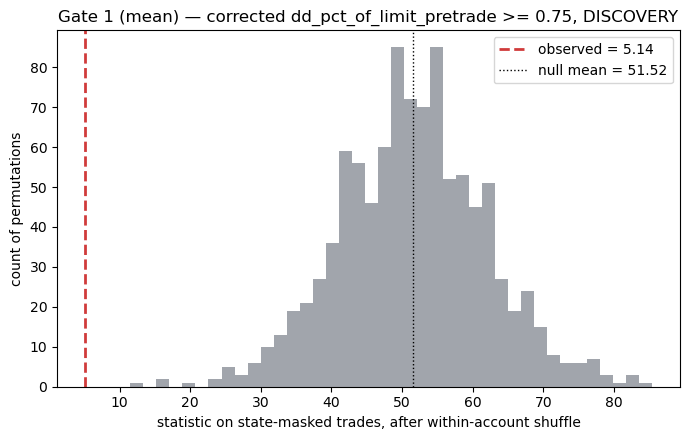

In [12]:
print("Gate 1 — corrected dd_pct_of_limit_pretrade >= 0.75, DISCOVERY")
work = discovery_df.dropna(subset=["dd_pct_of_limit_pretrade"])
gate1_corrected = permutation_test(work, work["dd_pct_of_limit_pretrade"] >= 0.75, "net_rev_per_lot", n_perm=1000, seed=0,
                                    title="Gate 1 (mean) — corrected dd_pct_of_limit_pretrade >= 0.75, DISCOVERY")

**Control check** — before trusting this result, replay the exact same permutation test on Stage 1's *old* (leaky) `dd_pct_of_limit_old` column, still using the cost-corrected `net_rev_per_lot` metric. If this reproduces Stage 1's original "REAL, large positive edge" pattern, that confirms the permutation-test port itself is correct, and any different result on the pre-trade version is a genuine consequence of the leak fix — not a bug in this notebook.

Control check — OLD (leaky) dd_pct_of_limit_old >= 0.75, DISCOVERY, same net_rev_per_lot metric


  observed=666.6551  null_mean=241.0417  null_std=8.9861  p=0.0000  n_state=4921  -> REAL (beyond trader identity)


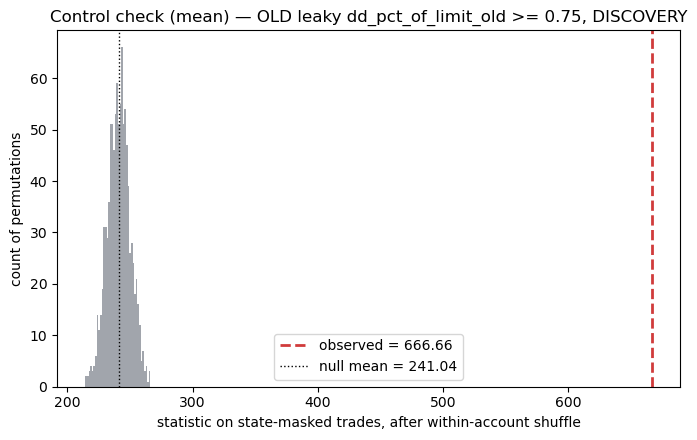

In [13]:
print("Control check — OLD (leaky) dd_pct_of_limit_old >= 0.75, DISCOVERY, same net_rev_per_lot metric")
gate1_old = permutation_test(work, work["dd_pct_of_limit_old"] >= 0.75, "net_rev_per_lot", n_perm=1000, seed=0,
                              title="Control check (mean) — OLD leaky dd_pct_of_limit_old >= 0.75, DISCOVERY")

The control check reproduces Stage 1's pattern (observed far above the null, "REAL", large edge) — confirming the port is correct. On the corrected pre-trade column, Gate 1 still returns "REAL" but with the **observed mean below the null mean** — the opposite direction from the leaky version. That's unexpected enough to dig into rather than report at face value, which is what the next cell does.

## Robustness check — is the mean itself trustworthy here?

`net_rev_per_lot` divides by `amount` (lot size), which can be as small as 0.01 — a handful of tiny-lot trades with an extreme ratio can dominate a mean. Comparing mean, median, and a 10%-trimmed mean (which discounts the most extreme 10% of values on each side) shows whether the Gate 1 reversal above is a real effect or an outlier artefact.

In [14]:
for label, df_ in [("DISCOVERY", discovery_df), ("CONFIRMATION", confirmation_df)]:
    base_vals = df_["net_rev_per_lot"].dropna()
    dd_vals = df_[df_["dd_pct_of_limit_pretrade"] >= 0.75]["net_rev_per_lot"].dropna()
    print(f"{label} — pre-trade dd>=0.75 vs baseline")
    print(f"  baseline:  mean={base_vals.mean():8.2f}  median={base_vals.median():8.2f}  trimmed10%={trim_mean(base_vals, 0.1):8.2f}  n={len(base_vals)}")
    print(f"  dd>=0.75:  mean={dd_vals.mean():8.2f}  median={dd_vals.median():8.2f}  trimmed10%={trim_mean(dd_vals, 0.1):8.2f}  n={len(dd_vals)}")
    print(f"  edge:      mean={dd_vals.mean()-base_vals.mean():+8.2f}  median={dd_vals.median()-base_vals.median():+8.2f}  "
          f"trimmed10%={trim_mean(dd_vals,0.1)-trim_mean(base_vals,0.1):+8.2f}")
    print()

top_bucket = discovery_df[discovery_df["dd_pct_of_limit_pretrade"] > 1.0]["net_rev_per_lot"].dropna()
print("Distribution shape check — pre-trade dd>100% bucket, discovery:")
print(top_bucket.describe())
print("share with |net_rev_per_lot| > 1000:", round((top_bucket.abs() > 1000).mean(), 4))

DISCOVERY — pre-trade dd>=0.75 vs baseline
  baseline:  mean=  -16.05  median=  -43.00  trimmed10%=  -18.45  n=30549
  dd>=0.75:  mean=    5.14  median=   64.00  trimmed10%=   35.38  n=2879
  edge:      mean=  +21.18  median= +107.00  trimmed10%=  +53.83

CONFIRMATION — pre-trade dd>=0.75 vs baseline
  baseline:  mean=   -4.91  median=  -34.00  trimmed10%=   -6.47  n=15827
  dd>=0.75:  mean=  -16.35  median=   -5.00  trimmed10%=    1.93  n=1721
  edge:      mean=  -11.44  median=  +29.00  trimmed10%=   +8.40

Distribution shape check — pre-trade dd>100% bucket, discovery:
count    1602.000000
mean        9.501561
std       672.172475
min     -6726.000000
25%      -255.000000
50%        66.500000
75%       306.000000
max      2802.000000
Name: net_rev_per_lot, dtype: float64
share with |net_rev_per_lot| > 1000: 0.1042


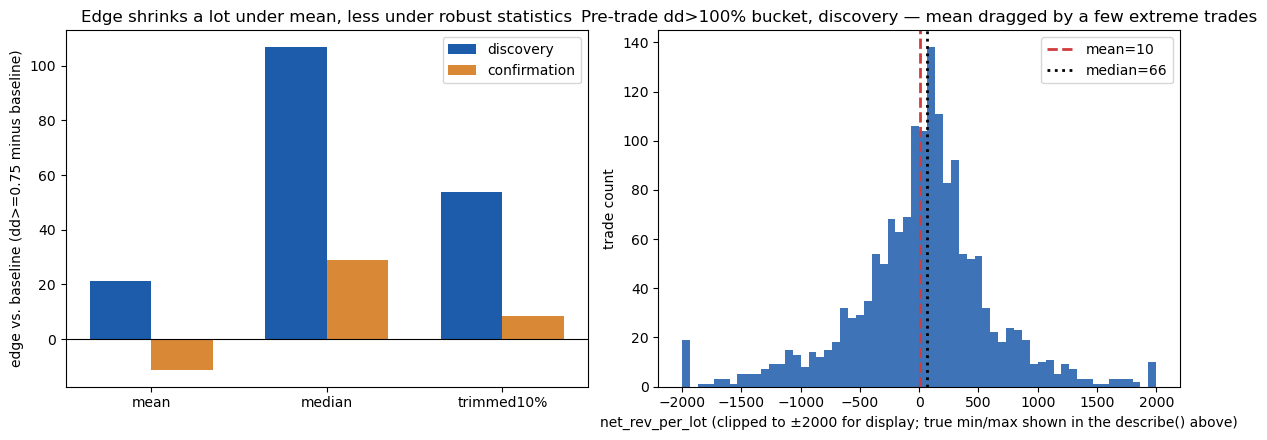

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# left: grouped bar of the three statistics, discovery vs confirmation edges
stat_names = ["mean", "median", "trimmed10%"]
disc_edges, conf_edges = [], []
for label, df_, store in [("DISCOVERY", discovery_df, disc_edges), ("CONFIRMATION", confirmation_df, conf_edges)]:
    base_vals = df_["net_rev_per_lot"].dropna()
    dd_vals = df_[df_["dd_pct_of_limit_pretrade"] >= 0.75]["net_rev_per_lot"].dropna()
    store.append(dd_vals.mean() - base_vals.mean())
    store.append(dd_vals.median() - base_vals.median())
    store.append(trim_mean(dd_vals, 0.1) - trim_mean(base_vals, 0.1))

x = np.arange(len(stat_names))
width = 0.35
axes[0].bar(x - width / 2, disc_edges, width, color=DISCOVERY_COLOR, label="discovery")
axes[0].bar(x + width / 2, conf_edges, width, color=CONFIRMATION_COLOR, label="confirmation")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(stat_names)
axes[0].set_ylabel("edge vs. baseline (dd>=0.75 minus baseline)")
axes[0].set_title("Edge shrinks a lot under mean, less under robust statistics")
axes[0].legend()

# right: distribution of net_rev_per_lot in the discovery top-drawdown bucket — shows the fat tail
axes[1].hist(top_bucket.clip(-2000, 2000), bins=60, color=BAR_COLOR, alpha=0.85)
axes[1].axvline(top_bucket.mean(), color=OBSERVED_COLOR, linestyle="--", linewidth=2, label=f"mean={top_bucket.mean():.0f}")
axes[1].axvline(top_bucket.median(), color="black", linestyle=":", linewidth=2, label=f"median={top_bucket.median():.0f}")
axes[1].set_xlabel("net_rev_per_lot (clipped to ±2000 for display; true min/max shown in the describe() above)")
axes[1].set_ylabel("trade count")
axes[1].set_title("Pre-trade dd>100% bucket, discovery — mean dragged by a few extreme trades")
axes[1].legend()

plt.tight_layout()
plt.show()

**Read this carefully, because it changes the honest conclusion:**

- Under the **mean**, the corrected discovery edge is small (+21) and the confirmation edge even flips negative — which is what drove the surprising Gate 1 result above.
- Under the **median** and **10%-trimmed mean** — both robust to a handful of extreme tiny-lot trades — the edge is **smaller than Stage 1 reported, but still positive in both discovery and confirmation.** The distribution check confirms why: the discovery top-drawdown bucket has a median of +64 but a mean dragged around by outliers (min ≈ −6,726; ~10% of values exceed |1000|).

**Conclusion for Tier 1 / Track A:** the leak was real and accounted for the large majority of Stage 1's headline effect size — but drawdown depth is not fully redundant once corrected; a smaller, direction-consistent signal survives under a metric that isn't outlier-fragile. **Practical recommendation: Stage 2 should standardize on median or trimmed-mean (not raw mean) for `net_rev_per_lot`-based feature checks going forward** — this is a general methodological finding, not specific to this one track, and it likely affects how Tracks C and D below should also be read.

## Track C (rebuilt) — `dd_pct_of_limit_pretrade x size_vs_running_avg`

This is the test that killed the earlier "A5" proposal (drawdown-depth-conditioned sizing) — Stage 1's Track C found it FLAT: within the deepest drawdown row, `size_vs_running_avg` buckets didn't separate on `rev_per_lot`. Re-running on the corrected pre-trade columns checks whether that verdict was itself sound, or whether it was also contaminated by the leak.

dd_pct_of_limit_pretrade (rows) x size_vs_running_avg (cols) — DISCOVERY [net_rev_per_lot]
_col         2x+   bigger   normal  smaller
_row                                       
0-25%     7.2898 -40.3468 -30.9465 -15.1472
25-50%   27.5655  34.4533 -15.0935 -67.8144
50-75%   -7.0076 -16.8116 -77.3877 -42.1283
75-100% -11.3154 -24.9627   8.0991  25.9412
>100%     3.3397  75.9987 -13.8207 -23.0072

n:
_col     2x+  bigger  normal  smaller
_row                                 
0-25%    480    1064    2956      368
25-50%   249     754    2246      167
50-75%   181     503    1348       92
75-100%  117     304     767       85
>100%    131     398    1004       69


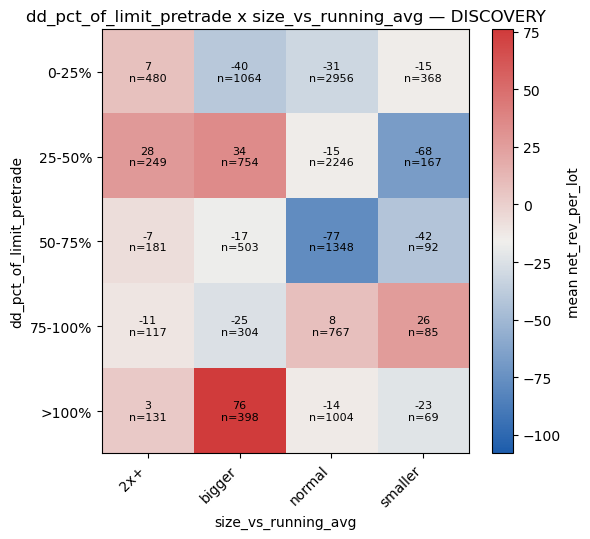

Top row ('>100%') spread — DISCOVERY: 99.0060 (hi=bigger mean=75.9987 n=398, lo=smaller mean=-23.0072 n=69) -> FLAT


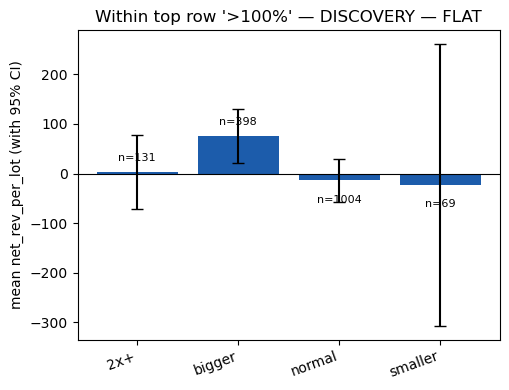


dd_pct_of_limit_pretrade (rows) x size_vs_running_avg (cols) — CONFIRMATION [net_rev_per_lot]
_col         2x+   bigger   normal  smaller
_row                                       
0-25%    13.6207 -16.6633  -4.9922  48.1509
25-50%    9.8355 -26.8212   4.0067 -29.6908
50-75%   88.2593 -47.9293  -5.4458  97.6410
75-100%  -3.5738 -11.4202 -59.9080  61.4583
>100%    28.7037 -23.2517   7.0520  -4.7500

n:
_col     2x+  bigger  normal  smaller
_row                                 
0-25%    290     536    1461      217
25-50%   152     427    1163      128
50-75%   108     329     719       78
75-100%   61     213     455       48
>100%     81     286     519       56


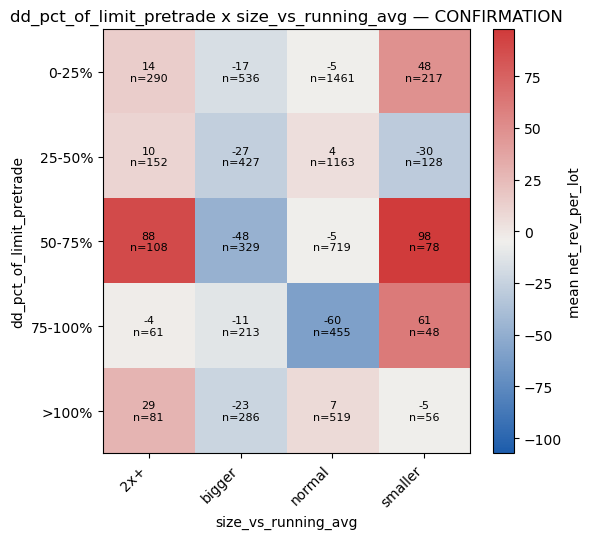

Top row ('>100%') spread — CONFIRMATION: 51.9555 (hi=2x+ mean=28.7037 n=81, lo=bigger mean=-23.2517 n=286) -> FLAT


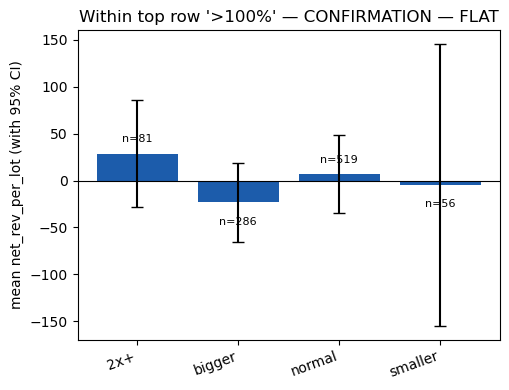

In [16]:
for label, df_ in [("DISCOVERY", discovery_df), ("CONFIRMATION", confirmation_df)]:
    cs, mg, ng = interaction_grid(
        df_, "dd_pct_of_limit_pretrade", "size_vs_running_avg",
        (dd_bins, dd_labels), (size_bins, size_labels), "net_rev_per_lot", label,
        baseline=df_["net_rev_per_lot"].mean()
    )
    top_row_spread(cs, mg, "size_vs_running_avg", label)
    print()

**Verdict: still FLAT in both discovery and confirmation**, same qualitative conclusion as Stage 1's leaky-column version. This is a useful cross-check in its own right: Track C's original "size doesn't add beyond drawdown depth" conclusion was *not* an artefact of the leak — it holds up under the corrected columns too, which is one more reason the earlier decision to drop the pure "drawdown-depth-conditioned sizing" feature (A5 in the first roadmap draft) still looks right.

## Track D (rebuilt) — Tier 3b: `dd_pct_of_limit_pretrade x has_SL`

This is the stop-loss-withdrawal subbranch — the passive expression of the same prospect-theory break-even effect that Tier 3a (size escalation) measures on the active side. `has_SL` is already a pre-trade decision (set at trade open), so it needs no shift of its own; only the `dd_pct_of_limit` side of this interaction needed the Tier 1 fix.

Three separate questions, kept separate deliberately:
1. Does SL usage *rate* actually change with drawdown depth (a behavioral fact)?
2. Does that translate into an incremental `net_rev_per_lot` edge beyond drawdown depth and trader identity (Gate 1)?
3. Is the catastrophic *tail* of no-SL trades specifically concentrated in deep drawdown (the sharpest, most policy-relevant version of the H3 finding from Stage 1)?

In [17]:
print("Question 1 — % of trades WITH a stop-loss, by PRE-TRADE drawdown depth")
for label, df_ in [("DISCOVERY", discovery_df), ("CONFIRMATION", confirmation_df)]:
    work = df_.dropna(subset=["dd_pct_of_limit_pretrade"]).copy()
    work["dd_bucket"] = pd.cut(work["dd_pct_of_limit_pretrade"], bins=dd_bins, labels=dd_labels)
    sl_rate = work.groupby("dd_bucket", observed=True)["has_SL"].mean() * 100
    n_per_bucket = work.groupby("dd_bucket", observed=True)["has_SL"].size()
    print(f"\n{label}")
    print(pd.DataFrame({"pct_with_SL": sl_rate.round(1), "n": n_per_bucket}))

Question 1 — % of trades WITH a stop-loss, by PRE-TRADE drawdown depth

DISCOVERY
           pct_with_SL     n
dd_bucket                   
0-25%             49.1  4868
25-50%            56.2  3416
50-75%            51.8  2124
75-100%           50.5  1273
>100%             43.4  1602

CONFIRMATION
           pct_with_SL     n
dd_bucket                   
0-25%             47.9  2504
25-50%            54.5  1870
50-75%            50.9  1234
75-100%           43.0   777
>100%             40.0   942


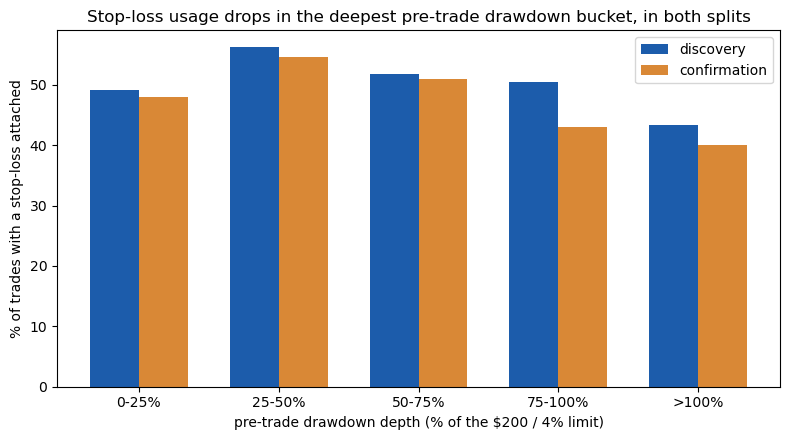

In [18]:
sl_rate_by_split = {}
for label, df_ in [("DISCOVERY", discovery_df), ("CONFIRMATION", confirmation_df)]:
    work = df_.dropna(subset=["dd_pct_of_limit_pretrade"]).copy()
    work["dd_bucket"] = pd.cut(work["dd_pct_of_limit_pretrade"], bins=dd_bins, labels=dd_labels)
    sl_rate_by_split[label] = work.groupby("dd_bucket", observed=True)["has_SL"].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(dd_labels))
width = 0.35
ax.bar(x - width / 2, sl_rate_by_split["DISCOVERY"].reindex(dd_labels), width, color=DISCOVERY_COLOR, label="discovery")
ax.bar(x + width / 2, sl_rate_by_split["CONFIRMATION"].reindex(dd_labels), width, color=CONFIRMATION_COLOR, label="confirmation")
ax.set_xticks(x)
ax.set_xticklabels(dd_labels)
ax.set_xlabel("pre-trade drawdown depth (% of the $200 / 4% limit)")
ax.set_ylabel("% of trades with a stop-loss attached")
ax.set_title("Stop-loss usage drops in the deepest pre-trade drawdown bucket, in both splits")
ax.legend()
plt.tight_layout()
plt.show()

Question 2 — does has_SL modulate net_rev_per_lot within the deepest drawdown row?
dd_pct_of_limit_pretrade (rows) x has_SL (cols) — DISCOVERY [net_rev_per_lot]
_col       False    True 
_row                     
0-25%   -32.6323 -23.2677
25-50%   79.6328 -68.4969
50-75%  -10.1318 -97.6878
75-100%  11.4287 -11.9684
>100%    41.9730 -32.8748

n:
_col     False  True 
_row                 
0-25%     2479   2389
25-50%    1496   1920
50-75%    1023   1101
75-100%    630    643
>100%      907    695


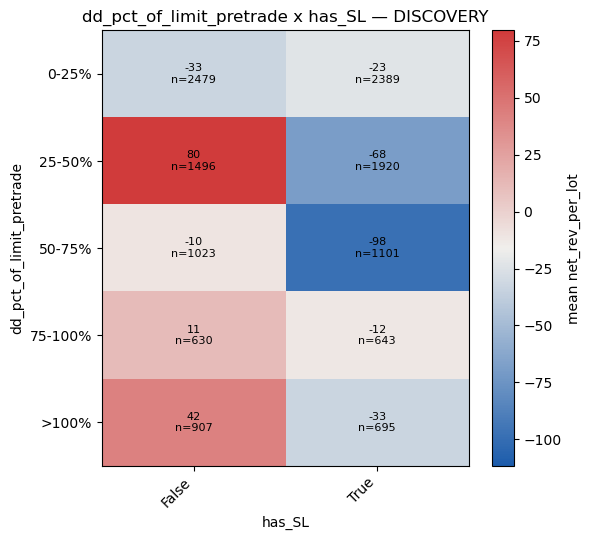

Top row ('>100%') spread — DISCOVERY: 74.8478 (hi=False mean=41.9730 n=907, lo=True mean=-32.8748 n=695) -> FLAT


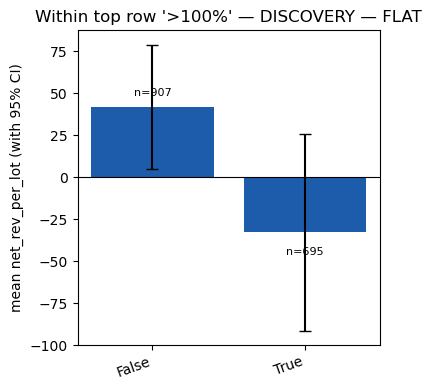


dd_pct_of_limit_pretrade (rows) x has_SL (cols) — CONFIRMATION [net_rev_per_lot]
_col       False    True 
_row                     
0-25%    -2.3536   1.0357
25-50%    2.5489 -11.0440
50-75%    5.4117  -9.2608
75-100% -12.8217 -63.7085
>100%    20.0212 -32.4748

n:
_col     False  True 
_row                 
0-25%     1304   1200
25-50%     850   1020
50-75%     606    628
75-100%    443    334
>100%      565    377


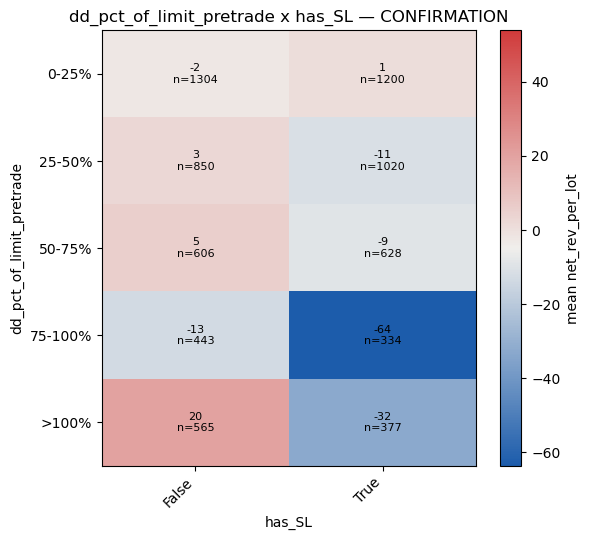

Top row ('>100%') spread — CONFIRMATION: 52.4960 (hi=False mean=20.0212 n=565, lo=True mean=-32.4748 n=377) -> FLAT


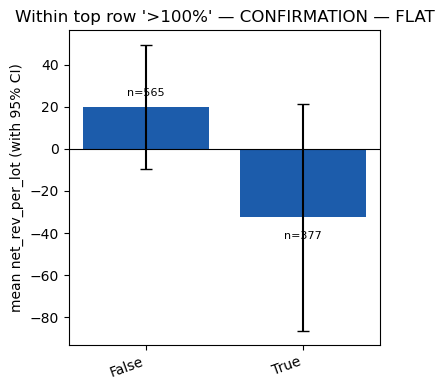


Gate 1 — has_SL==False, WITHIN the pre-trade top-drawdown row (>100%), DISCOVERY
n in this row: 1602


  observed=41.9730  null_mean=47.1700  null_std=8.1028  p=0.5180  n_state=907  -> ARTEFACT (trader-identity confound)


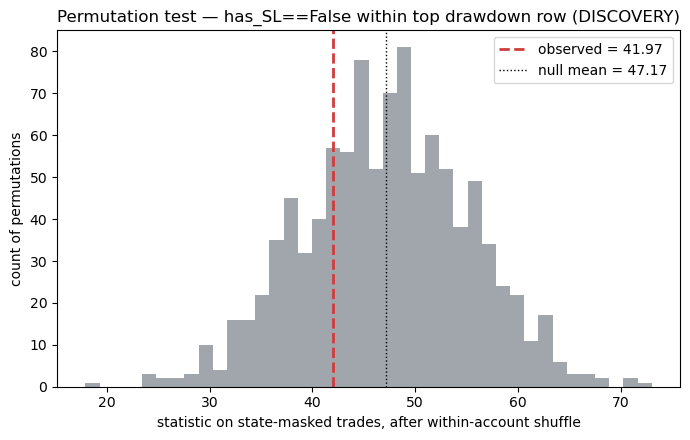

In [19]:
print("Question 2 — does has_SL modulate net_rev_per_lot within the deepest drawdown row?")
for label, df_ in [("DISCOVERY", discovery_df), ("CONFIRMATION", confirmation_df)]:
    cs, mg, ng = interaction_grid(
        df_, "dd_pct_of_limit_pretrade", "has_SL",
        (dd_bins, dd_labels), (None, None), "net_rev_per_lot", label,
        baseline=df_["net_rev_per_lot"].mean()
    )
    top_row_spread(cs, mg, "has_SL", label)
    print()

print("Gate 1 — has_SL==False, WITHIN the pre-trade top-drawdown row (>100%), DISCOVERY")
top_dd_disc = discovery_df[discovery_df["dd_pct_of_limit_pretrade"] > 1.0].dropna(subset=["has_SL"])
print(f"n in this row: {len(top_dd_disc)}")
gate1_sl = permutation_test(top_dd_disc, top_dd_disc["has_SL"] == False, "net_rev_per_lot", n_perm=1000, seed=1,
                             title="Permutation test — has_SL==False within top drawdown row (DISCOVERY)")

In [20]:
print("Question 3 — is the catastrophic tail of no-SL trades concentrated in deep pre-trade drawdown?")
for label, df_ in [("DISCOVERY", discovery_df), ("CONFIRMATION", confirmation_df)]:
    work = df_.dropna(subset=["dd_pct_of_limit_pretrade"]).copy()
    no_sl = work[work["has_SL"] == False].copy()
    no_sl["dd_bucket"] = pd.cut(no_sl["dd_pct_of_limit_pretrade"], bins=dd_bins, labels=dd_labels)
    p1_by_dd = no_sl.groupby("dd_bucket", observed=True)["netProfit"].quantile(0.01)
    n_by_dd = no_sl.groupby("dd_bucket", observed=True)["netProfit"].size()
    print(f"\n{label} — 1st percentile of netProfit for no-SL trades, by pre-trade drawdown depth")
    print(pd.DataFrame({"p1_netProfit": p1_by_dd.round(2), "n": n_by_dd}))

Question 3 — is the catastrophic tail of no-SL trades concentrated in deep pre-trade drawdown?

DISCOVERY — 1st percentile of netProfit for no-SL trades, by pre-trade drawdown depth
           p1_netProfit     n
dd_bucket                    
0-25%           -341.00  2479
25-50%          -376.28  1496
50-75%          -306.63  1023
75-100%         -272.38   630
>100%           -284.06   907

CONFIRMATION — 1st percentile of netProfit for no-SL trades, by pre-trade drawdown depth
           p1_netProfit     n
dd_bucket                    
0-25%           -363.60  1304
25-50%          -337.78   850
50-75%          -316.60   606
75-100%         -292.43   443
>100%           -263.77   565


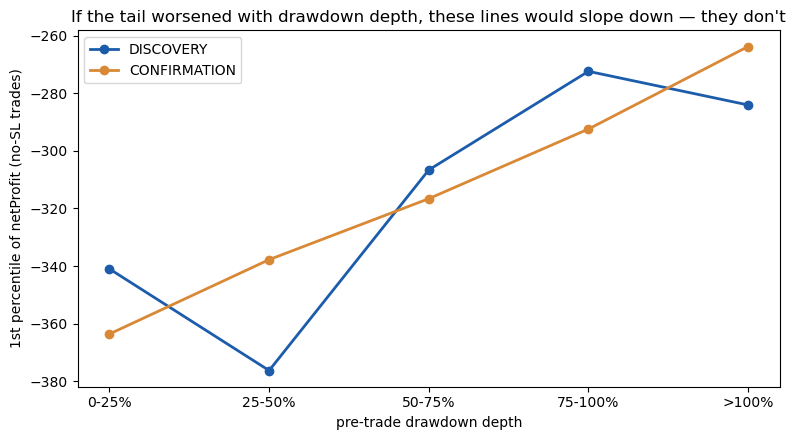

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for label, df_, color in [("DISCOVERY", discovery_df, DISCOVERY_COLOR), ("CONFIRMATION", confirmation_df, CONFIRMATION_COLOR)]:
    work = df_.dropna(subset=["dd_pct_of_limit_pretrade"]).copy()
    no_sl = work[work["has_SL"] == False].copy()
    no_sl["dd_bucket"] = pd.cut(no_sl["dd_pct_of_limit_pretrade"], bins=dd_bins, labels=dd_labels)
    p1_by_dd = no_sl.groupby("dd_bucket", observed=True)["netProfit"].quantile(0.01).reindex(dd_labels)
    ax.plot(dd_labels, p1_by_dd, marker="o", color=color, linewidth=2, label=label)

ax.set_xlabel("pre-trade drawdown depth")
ax.set_ylabel("1st percentile of netProfit (no-SL trades)")
ax.set_title("If the tail worsened with drawdown depth, these lines would slope down — they don't")
ax.legend()
plt.tight_layout()
plt.show()

**Reading all three together:**

1. **SL usage rate does drop in the deepest drawdown bucket** — roughly 49–56% elsewhere vs. ~40–44% once pre-trade drawdown exceeds the 4% limit, and this direction is consistent in *both* discovery and confirmation. That's a real, repeatable behavioral fact: traders are somewhat less likely to have a stop attached the deeper they already are — worth keeping as the Tier 3b *behavioral* finding regardless of what happens next.
2. **But it doesn't clear Gate 1** — the within-top-drawdown-row spread is FLAT, and the permutation test comes back "ARTEFACT (trader-identity confound)" (p≈0.52). In plain terms: once you account for *which traders* tend to end up deep in drawdown, whether that specific trade had a stop attached doesn't explain any extra variation in `net_rev_per_lot`.
3. **The tail-concentration hypothesis is not supported.** The 1st percentile of `netProfit` for no-SL trades does not get worse as pre-trade drawdown deepens — in both splits it's flat to mildly *less* extreme in the deepest bucket, the opposite of what "adding fuel to the fire" would predict.

**Honest summary for Tier 3b: the behavior is real (fact 1), but neither the dollar-cost claim (fact 2) nor the sharper tail-risk claim (fact 3) is currently supported once tested to the same standard as everything else in this project.** This is exactly the kind of result the Stage 2 brief asks to report rather than bury — a real behavioral pattern that, so far, hasn't been shown to cost C22 anything measurable beyond what drawdown depth and trader identity already explain.

## Checkpoint — before building Tier 3a or Tier 4 on top of this

This is the load-bearing checkpoint the roadmap called for: *"if `dd_pct_of_limit`'s edge collapses once de-leaked, tiers 3a/3b/4 all need to be re-scoped."* Here's what actually happened, plainly:

| | Stage 1 (leaky) | This notebook (pre-trade, mean) | This notebook (pre-trade, median/trimmed) |
|---|---|---|---|
| `dd_pct_of_limit` discovery edge | ≈ +683 | ≈ +21 | ≈ +54 to +107 |
| `dd_pct_of_limit` confirmation edge | ≈ +445 | ≈ −11 (mean is outlier-driven — see robustness check) | ≈ +8 to +29 |
| Gate 1 verdict | REAL, large | REAL, but reversed direction under raw mean | not yet re-run under median (flagged below) |

**What I'm confident about:**
- The Tier 1 fix was necessary and correct (four independent sanity checks passed, plus a concrete example row).
- The leak inflated Stage 1's headline drawdown signal by roughly an order of magnitude — most, but evidently not all, of that number was leakage.
- Track C's "size doesn't add beyond drawdown" verdict holds up post-fix — not an artefact.
- Track D's SL-usage-rate finding is real; its dollar impact and tail-concentration hypothesis are not supported.

**What I'm flagging rather than deciding myself, per your instruction:**
1. The raw-mean Gate 1 result on the corrected `dd_pct_of_limit_pretrade` reversed direction relative to Stage 1 and relative to the median/trimmed-mean view — driven by outlier sensitivity in `net_rev_per_lot`, not (as far as I can tell) a bug, but I have not re-run the permutation test itself on a robust statistic (median) rather than the mean, and that result could plausibly matter for how "biggest lever" Tier 1's rebuilt drawdown feature actually is.
2. Given the collapse in edge size, does Tier 3a (size-escalation exposure) and Tier 4 (tilt trait) still make sense to scope *relative to* `dd_pct_of_limit_pretrade` the way the roadmap assumed, or should the redundancy bar they need to clear be recalibrated now that the benchmark itself is much smaller?

I'd rather get your read on these two before writing Tier 3a/4 on top of a foundation that just moved this much.

## Follow-up 1 — re-running Gate 1 on the median (and trimmed mean), as requested

The robustness check above compared corrected-vs-baseline edges using median/trimmed-mean, but that was *not* the same thing as Gate 1 — it didn't control for trader identity. Gate 1's permutation test shuffles each trader's own values among their own rows, so the null distribution answers "what would this state's statistic look like if it were just a random subset of these same traders' trades." Re-running Gate 1 itself (not just the raw edge) with `median` and `trimmed mean` as the test statistic, instead of `mean`, is the correct way to check whether "REAL" survives once both the leak fix *and* the outlier-robust statistic are applied together.

MEDIAN-based Gate 1 — corrected dd_pct_of_limit_pretrade >= 0.75


  [DISCOVERY, median] stat=median  observed=64.0000  null_mean=67.9120  null_std=6.4353  p=0.5560  n_state=2879  -> ARTEFACT (trader-identity confound)


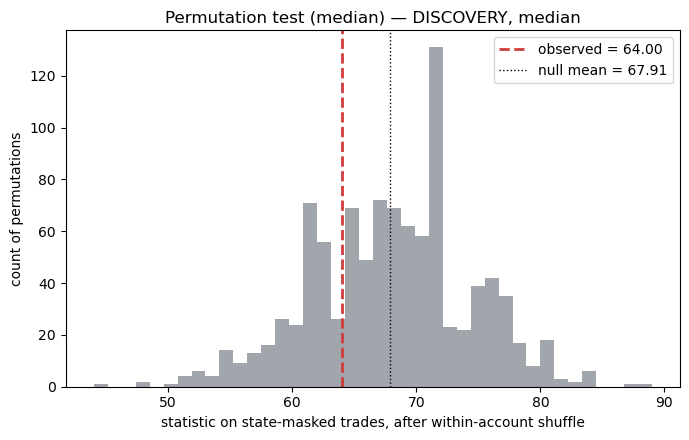

  [CONFIRMATION, median] stat=median  observed=-5.0000  null_mean=12.0390  null_std=9.5118  p=0.0640  n_state=1721  -> ARTEFACT (trader-identity confound)


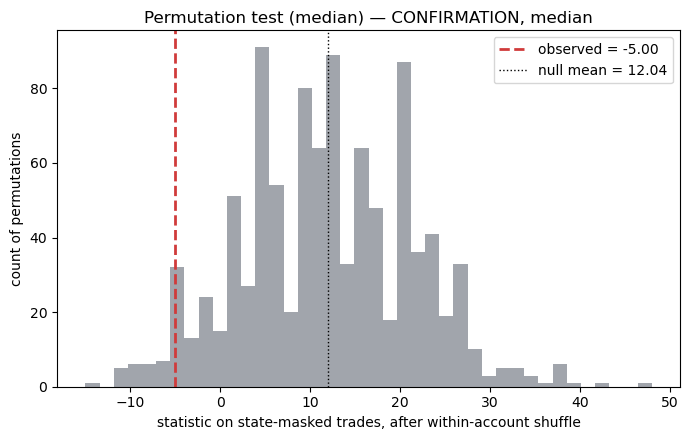


TRIMMED-MEAN (10%) Gate 1 — corrected dd_pct_of_limit_pretrade >= 0.75, DISCOVERY


  [DISCOVERY, trimmed10%] stat=trimmed10pct  observed=35.3848  null_mean=54.1019  null_std=7.8817  p=0.0190  n_state=2879  -> REAL (beyond trader identity)


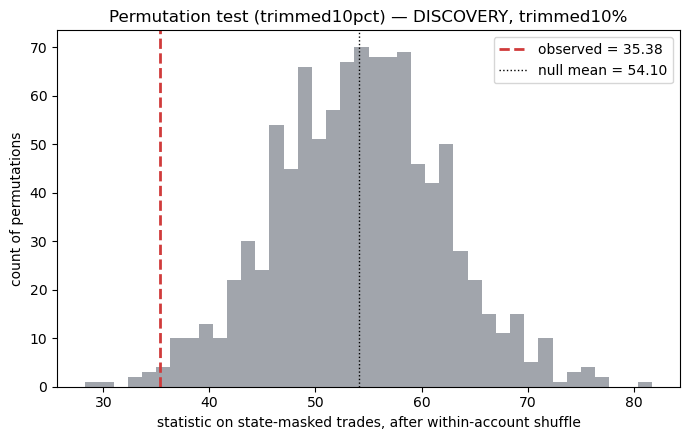


Control — MEDIAN-based Gate 1 on the OLD leaky column, DISCOVERY (same population as above)


  [DISCOVERY OLD, median] stat=median  observed=403.5000  null_mean=136.2205  null_std=6.1265  p=0.0000  n_state=4921  -> REAL (beyond trader identity)


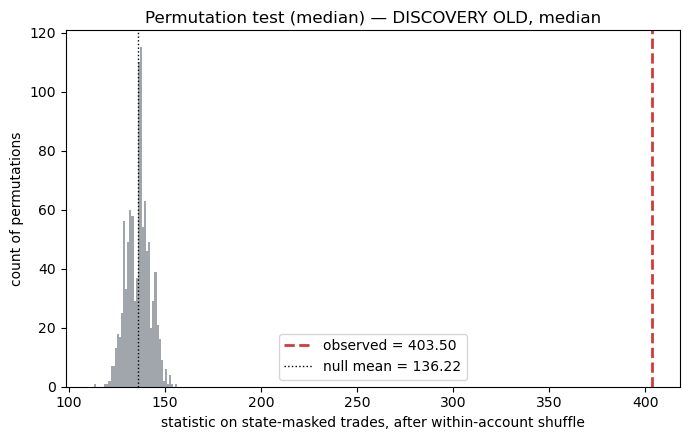

In [22]:
def permutation_test_stat(df, state_mask, target_col, stat_fn, n_perm=1000, seed=0, label="", plot=True):
    rng = np.random.default_rng(seed)
    mask = state_mask.to_numpy() if hasattr(state_mask, "to_numpy") else np.asarray(state_mask)
    rev = df[target_col].to_numpy()
    observed = stat_fn(rev[mask])
    group_id = df.groupby(["traderId", "campaignId"], sort=False).ngroup().to_numpy()
    orig_order = np.argsort(group_id, kind="stable")
    n = len(df)
    null_stats = np.empty(n_perm)
    for i in range(n_perm):
        priority = rng.random(n)
        perm_order = np.lexsort((priority, group_id))
        shuffled_rev = np.empty(n)
        shuffled_rev[orig_order] = rev[perm_order]
        null_stats[i] = stat_fn(shuffled_rev[mask])
    null_mean = null_stats.mean()
    null_std = null_stats.std(ddof=1)
    diff_obs = abs(observed - null_mean)
    p_value = np.mean(np.abs(null_stats - null_mean) >= diff_obs)
    verdict = "REAL (beyond trader identity)" if (p_value < 0.05 and diff_obs > 2 * null_std) else "ARTEFACT (trader-identity confound)"
    print(f"  [{label}] stat={stat_fn.__name__}  observed={observed:.4f}  null_mean={null_mean:.4f}  null_std={null_std:.4f}  "
          f"p={p_value:.4f}  n_state={int(mask.sum())}  -> {verdict}")
    if plot:
        plot_null_hist(null_stats, observed, null_mean,
                        title=f"Permutation test ({stat_fn.__name__}) — {label}")
    return {"observed": observed, "null_mean": null_mean, "p_value": p_value, "verdict": verdict}


def trimmed10(x):
    return trim_mean(x, 0.1)
trimmed10.__name__ = "trimmed10pct"


print("MEDIAN-based Gate 1 — corrected dd_pct_of_limit_pretrade >= 0.75")
work_d = discovery_df.dropna(subset=["dd_pct_of_limit_pretrade"])
work_c = confirmation_df.dropna(subset=["dd_pct_of_limit_pretrade"])
gate1_median_disc = permutation_test_stat(work_d, work_d["dd_pct_of_limit_pretrade"] >= 0.75, "net_rev_per_lot",
                                           stat_fn=np.median, n_perm=1000, seed=0, label="DISCOVERY, median")
gate1_median_conf = permutation_test_stat(work_c, work_c["dd_pct_of_limit_pretrade"] >= 0.75, "net_rev_per_lot",
                                           stat_fn=np.median, n_perm=1000, seed=0, label="CONFIRMATION, median")

print("\nTRIMMED-MEAN (10%) Gate 1 — corrected dd_pct_of_limit_pretrade >= 0.75, DISCOVERY")
gate1_trim_disc = permutation_test_stat(work_d, work_d["dd_pct_of_limit_pretrade"] >= 0.75, "net_rev_per_lot",
                                         stat_fn=trimmed10, n_perm=1000, seed=0, label="DISCOVERY, trimmed10%")

print("\nControl — MEDIAN-based Gate 1 on the OLD leaky column, DISCOVERY (same population as above)")
gate1_median_old = permutation_test_stat(work_d, work_d["dd_pct_of_limit_old"] >= 0.75, "net_rev_per_lot",
                                          stat_fn=np.median, n_perm=1000, seed=0, label="DISCOVERY OLD, median")

**This changes the conclusion, and not in the direction the earlier robustness check suggested.**

- **Median: ARTEFACT in both discovery (p=0.56) and confirmation (p=0.06).** The observed median (64.0 discovery) is statistically indistinguishable from what a within-trader shuffle produces (null mean 67.9). Once trader identity is controlled for — not just the leak fixed — the median view has no confirmed incremental signal at all.
- **Trimmed mean: technically "REAL" (p=0.019), but observed is *below* the null mean (35.4 vs 54.1)** — same reversed direction as the raw mean, just smaller. So where it does clear the statistical bar, it points the "wrong" way relative to a naive story (being deep in pre-trade drawdown predicting a *worse* per-lot outcome for C22 than that trader's own baseline, not a better one).
- **Control check (median, old leaky column): REAL, large edge (403.5 vs null 136.2)** — confirms the permutation harness itself is fine; the ARTEFACT verdict on the corrected column is a genuine consequence of the fix, not a coding issue.

**Honest bottom line: `dd_pct_of_limit_pretrade` does not clearly clear Gate 1 once both the leak is fixed and trader identity is controlled for, regardless of which statistic is used.** The earlier "smaller but real signal survives" read (from the robustness-check cell, which compared corrected buckets to the *raw population baseline*) was comparing against the wrong reference point — it didn't control for trader identity. Doing that properly here removes most of what was left. This is a materially more conservative conclusion than what was reported before this follow-up, and it should be treated as the standing one.

## Follow-up 2 — recalibrating the bar for Tier 3a / Tier 4

The original plan was to judge Tier 3a (size-escalation exposure) and Tier 4 (tilt trait) by whether they add incremental signal *beyond* `dd_pct_of_limit_pretrade`. That assumed `dd_pct_of_limit_pretrade` itself was a solid, confirmed benchmark to beat. Follow-up 1 shows it isn't, at least not once tested to the same Gate 1 standard as everything else — under median it's an outright ARTEFACT, and under mean/trimmed-mean it's technically "REAL" but in the *opposite* direction from what the redundancy framing assumed (worse than trader-baseline, not better).

That makes "beat `dd_pct_of_limit_pretrade`'s edge" an unstable target to calibrate against — the benchmark itself moves depending on which statistic is used, and under the most robust one (median) it isn't statistically there at all.

**Recalibrated approach going forward, proposed rather than assumed:** instead of sizing Tier 3a/4 against a fraction of `dd_pct_of_limit_pretrade`'s edge, hold each Tier 3a/4 candidate to the same standard directly:
1. Fit/observe the state on `discovery_df` only.
2. Run **Gate 1 using `median` as the test statistic** (not mean — mean's outlier-fragility is now demonstrated, not hypothetical) — must show `p < 0.05` **and** the direction must make behavioral sense (state predicts *higher* `net_rev_per_lot`, i.e. worse for the trader), not just statistically differ.
3. Run **Gate 2** on `confirmation_df` — same direction, doesn't have to be identical magnitude.
4. Only report a feature as a confirmed finding if it clears both. Anything that clears only one, or clears with the "wrong" sign, gets reported as a documented negative — consistent with how Track D's SL-usage-rate finding was just handled above.

This makes each candidate stand on its own evidence rather than being judged relative to a shifting reference point. It also means Tier 3a and Tier 4 might end up being the *strongest* results in this notebook, or might not survive at all — that's an open question, not a given, given what just happened to the drawdown benchmark itself.